# Reshaping metadata

Source files with medatata providing via different files. Some data are privacy sensitive (f.e. mapping KYH study ID with 16S sequencing library id ) 

So I aggregate required field into CSV files

- `kyh_metadata.csv` contains open clinical and personal data from KYH study
- `kyh_variables_description.csv` human readable descriptions for columns names from kyh_metadata.csv
- `kyh_ids_map.csv` _private_ mapping KYH study ID with 16S sequencing library id 
- `SraRunTable.csv` intact sra accesses from NCBI SRA Run Selector

`all_meta.csv` _private_ kyh_metadata.csv with Run Id from SraRunTable.csv (mapped via kyh_ids_map.csv)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
METADATA_DIR = Path("resources/metadata")

In [3]:
BATCHES_SIZE = 100

In [4]:
SAVE_RESULTS = True

## Load metadata sets

In [5]:
kyh_df = pd.read_stata(METADATA_DIR / "260505_Alex_Zobolev.dta", index_col='KYH_ID')
kyh_df = kyh_df.replace({'-999': pd.NA})
kyh_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2380 entries, 1121127 to 1029104
Data columns (total 55 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   hcd_date              2380 non-null   datetime64[ns]
 1   d_sex                 2380 non-null   category      
 2   d_age_hc              2380 non-null   float64       
 3   d_age_hc_grp_10yr     2380 non-null   category      
 4   d_age_hc_grp_5yr      2380 non-null   category      
 5   b_a9                  2380 non-null   category      
 6   bd_education3_vs      2380 non-null   category      
 7   bd_phq9_sev_score     2380 non-null   int8          
 8   bd_phq9_dep_alt       2380 non-null   category      
 9   bd_phq9_symptomcount  2380 non-null   int8          
 10  bd_phq9_dep_cat       2380 non-null   category      
 11  bd_phq9_any_dep       2380 non-null   category      
 12  bd_phq9_mod_dep       2380 non-null   category      
 13  b_e1          

In [6]:
kyh_variables = pd.read_excel(METADATA_DIR / 'Ark_Dataset_description.xlsx', index_col=0)
kyh_variables = pd.concat([kyh_variables, pd.DataFrame.from_dict(
    {f'atc{n}': f'ATC group coding of medication {n}' for n in range(1, 8) },
    columns=['Label'],
    orient='index'
)])

In [7]:
sra_table = pd.read_csv(METADATA_DIR / "SraRunTable.csv", index_col="Sample Name")
sra_table.head()

,Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center Name,Collection_Date,...,Library Name,LibraryLayout,LibrarySelection,LibrarySource,Organism,Platform,ReleaseDate,create_date,version,SRA Study
Sample Name,,,,,,,,,,,,,,,,,,,,,
KYH512155,SRR32393053,AMPLICON,500,23148500,PRJNA1225157,SAMN46890594,"MIMS.me,MIGS/MIMS/MIMARKS.human-gut",13457009,RESEARCH INSTITUTE FOR SYSTEMS BIOLOGY AND MED...,2016-09-06/2017-11-27,...,KYH512155,PAIRED,PCR,METAGENOMIC,human gut metagenome,ILLUMINA,2025-03-07T00:00:00Z,2025-02-19T06:22:00Z,1,SRP564871
KYH950050,SRR32393054,AMPLICON,501,13156273,PRJNA1225157,SAMN46891187,"MIMS.me,MIGS/MIMS/MIMARKS.human-gut",8161868,RESEARCH INSTITUTE FOR SYSTEMS BIOLOGY AND MED...,2016-09-06/2017-11-27,...,KYH950050,PAIRED,PCR,METAGENOMIC,human gut metagenome,ILLUMINA,2025-03-07T00:00:00Z,2025-02-19T06:22:00Z,1,SRP564871
KYH337127,SRR32393055,AMPLICON,501,16897469,PRJNA1225157,SAMN46891186,"MIMS.me,MIGS/MIMS/MIMARKS.human-gut",9919188,RESEARCH INSTITUTE FOR SYSTEMS BIOLOGY AND MED...,2016-09-06/2017-11-27,...,KYH337127,PAIRED,PCR,METAGENOMIC,human gut metagenome,ILLUMINA,2025-03-07T00:00:00Z,2025-02-19T06:22:00Z,1,SRP564871
KYH643147,SRR32393056,AMPLICON,501,16019213,PRJNA1225157,SAMN46891185,"MIMS.me,MIGS/MIMS/MIMARKS.human-gut",10286511,RESEARCH INSTITUTE FOR SYSTEMS BIOLOGY AND MED...,2016-09-06/2017-11-27,...,KYH643147,PAIRED,PCR,METAGENOMIC,human gut metagenome,ILLUMINA,2025-03-07T00:00:00Z,2025-02-19T06:22:00Z,1,SRP564871
KYH619523,SRR32393057,AMPLICON,501,21237212,PRJNA1225157,SAMN46891184,"MIMS.me,MIGS/MIMS/MIMARKS.human-gut",12225672,RESEARCH INSTITUTE FOR SYSTEMS BIOLOGY AND MED...,2016-09-06/2017-11-27,...,KYH619523,PAIRED,PCR,METAGENOMIC,human gut metagenome,ILLUMINA,2025-03-07T00:00:00Z,2025-02-19T06:22:00Z,1,SRP564871


In [8]:
ids_map = pd.read_csv(METADATA_DIR / "old_metadata_with_ids_mappings.csv", sep=';', index_col='ID_KYH')
ids_map.head()

,df_sample,Unnamed: 0,batch,batch2,rep,ID_Dima,ID_David,main_group,site,date_of_brth,...,high_hba1c,diabetes_medical,drinking_level,ISCO_group,anti_inflammatory_med,PPI_med,antibiotics_med,lipid_mod_agents_med,antidiab_med,new_id
ID_KYH,,,,,,,,,,,,,,,,,,,,,
1084344,1084344_B1,1084344_B1,B1,B1,NaN,1,1,Arkhangelsk main study,Arkhangelsk,18.06.1950,...,yes,yes,Non-problem drinkers,High skilled white collar (ISCO codes 1-3),no,no,no,no,no,KYH272685
1068937,1068937_B1,1068937_B1,B1,B1,NaN,1,1,Arkhangelsk main study,Arkhangelsk,11.07.1968,...,no,no,Non-problem drinkers,High skilled blue collar (ISCO codes 6-7),no,no,no,no,no,KYH879167
1152946,1152946_B1,1152946_B1,B1,B1,NaN,1,1,Arkhangelsk main study,Arkhangelsk,25.11.1974,...,no,no,Non-problem drinkers,High skilled white collar (ISCO codes 1-3),no,no,no,no,no,KYH518700
1127440,1127440_B1,1127440_B1,B1,B1,NaN,1,1,Arkhangelsk main study,Arkhangelsk,17.10.1973,...,no,no,Non-problem drinkers,High skilled white collar (ISCO codes 1-3),no,no,no,no,no,KYH444549
1118366,1118366_B1,1118366_B1,B1,B1,NaN,1,1,Arkhangelsk main study,Arkhangelsk,11.04.1956,...,no,no,Non-problem drinkers,Low skilled white collar (ISCO codes 4-5),no,no,no,no,no,KYH552241


## Map human readable descriptions for metadata

In [9]:
print(kyh_df.columns[ ~ kyh_df.columns.isin(kyh_variables.index)])
kyh_variables = kyh_variables.loc[kyh_df.columns[kyh_df.columns.isin(kyh_variables.index)]]

Index([], dtype='object')


In [10]:
kyh_variables.to_csv(METADATA_DIR / "kyh_variables_description.csv")
kyh_variables = pd.read_csv(METADATA_DIR / "kyh_variables_description.csv", index_col=0)

## Filter KYH metadata 

Select KYH metadata by 16s sequencing library ids

### Find out are there unmatched indexes

In [11]:
print('sra_table, ids_map:', len(sra_table.index.symmetric_difference(ids_map['new_id'])))
print('kyh_df, ids_map:', len(ids_map.index[ ~ids_map.index.isin(kyh_df.index)]))

sra_table, ids_map: 0
kyh_df, ids_map: 0


In [12]:
kyh_df = kyh_df.loc[ids_map.index]

## Medications 

Discover the reception of __antibiotics__ (ATC code `J01`) or __antidepressants__ (ATC code `N06A`)

In [13]:
atc_cols = [f'atc{i}' for i in range(1, 8)]
def isMedicationUsage(df, ATCCode, new_col_name) -> pd.DataFrame:
    df[new_col_name] = (
        df[atc_cols]
        .astype(str)
        .apply(lambda col: col.str.startswith(ATCCode, na=False))
        .any(axis=1)
    )
    return df

kyh_df = isMedicationUsage(kyh_df, 'N06A', 'antidepressant_usage')
kyh_df = isMedicationUsage(kyh_df, 'J01', 'antibiotics_usage')
kyh_df[['antidepressant_usage', 'antibiotics_usage']].sum()

antidepressant_usage    0
antibiotics_usage       2
dtype: int64

Filter out patient taken antibiotics (2 samples) and antidepressant_usage (0 samples)

In [14]:
kyh_df = kyh_df[~ kyh_df[['antidepressant_usage', 'antibiotics_usage']].any(axis=1)]

## Depression summary

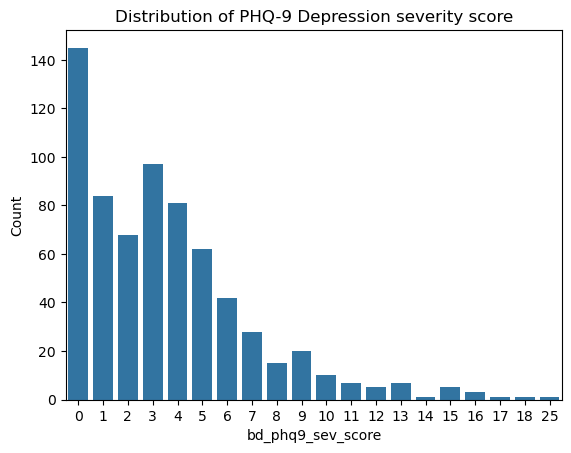

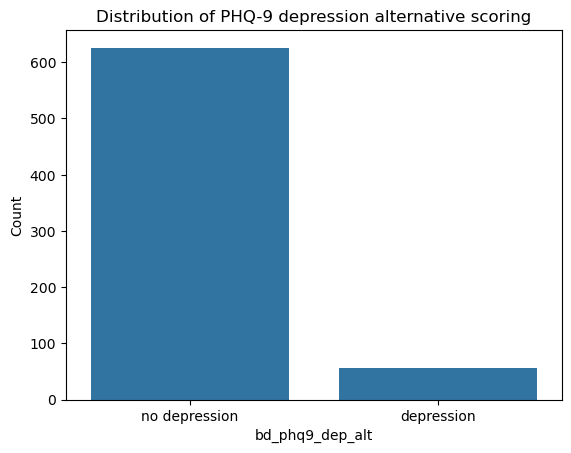

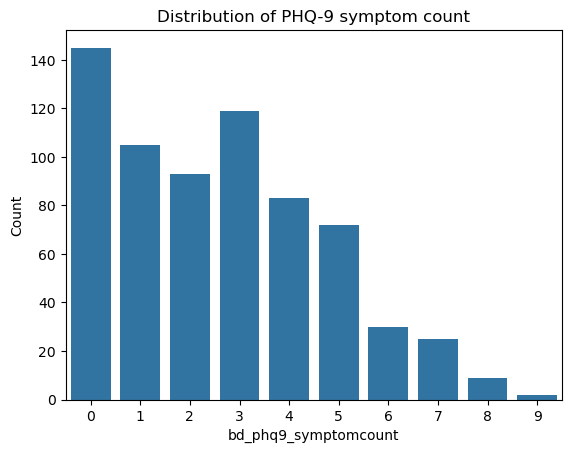

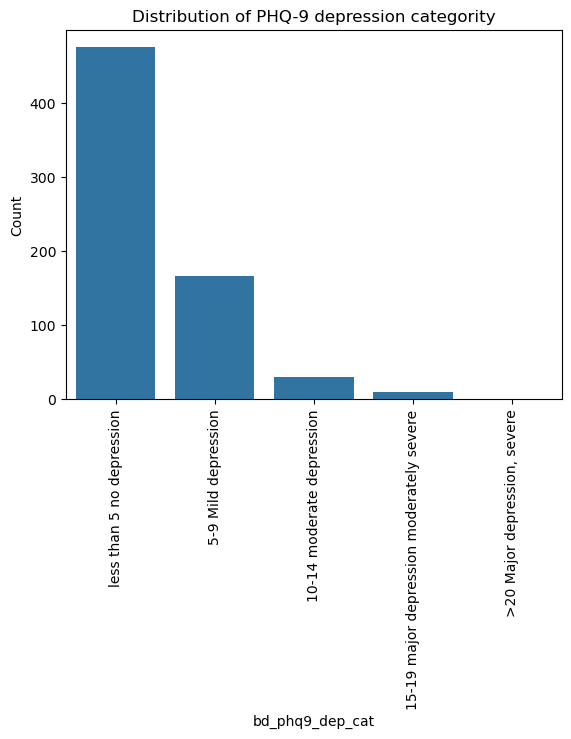

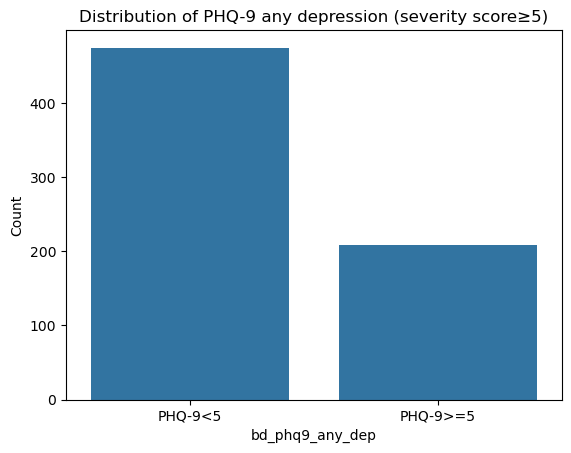

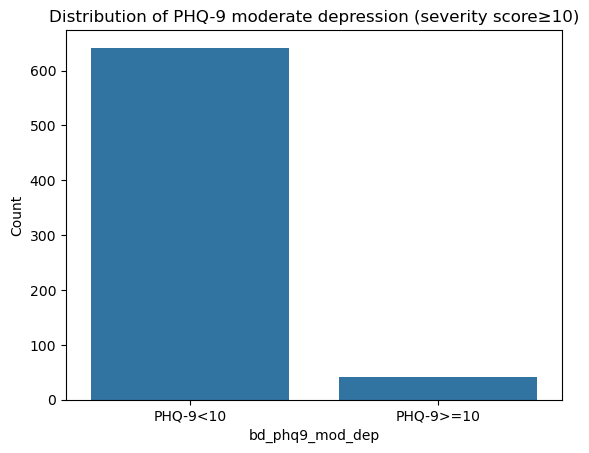

In [15]:
def depr_summary_plot(df, col_name):
    sns.countplot(x=col_name, data=df)
    plt.title(f'Distribution of {kyh_variables.loc[col_name, "Label"]}')
    plt.xlabel(col_name)
    plt.ylabel('Count')
    if (any(  df[col_name].dropna().astype(str).str.len() > 5 + 20 / len(df[col_name].unique()) )):
        plt.xticks(rotation=90)
    plt.show()
    
for col in kyh_df.loc[:,'bd_phq9_sev_score':'bd_phq9_mod_dep']:
    depr_summary_plot(kyh_df, col)

## Season

Compare _Date faecal sample was collected by participant_ (`lab_lc_w8b`) vs. _Date of Health Check_ (`hcd_date`) 

If `lab_lc_w8b` is empty, i will use `hcd_date` instead

In [16]:
kyh_df['lab_lc_w8b'] = kyh_df['lab_lc_w8b'].replace({'97': pd.NA}) # i really don't know what 97 means, but it is not a valid date, so I will treat it as missing value
kyh_df['lab_lc_w8b'] = pd.to_datetime(kyh_df['lab_lc_w8b'], format='mixed')

In [17]:
season = ['cold', 'cold', 'warm', 'warm', 'warm', 'warm', 'warm', 'warm', 'cold', 'cold', 'cold', 'cold']
kyh_df['season'] = kyh_df['lab_lc_w8b'].fillna(kyh_df['hcd_date']).dt.month.apply(lambda x: season[int(x)-1])

In [18]:
table = kyh_df.pivot_table(
    index='bd_phq9_any_dep',
    columns='season',
    aggfunc='size',
    fill_value=0,
    observed=True 
)
table

season,cold,warm
bd_phq9_any_dep,,
PHQ-9<5,256,219
PHQ-9>=5,101,107


In [19]:
from scipy.stats import chi2_contingency
pd.DataFrame(chi2_contingency(table), index=['Chi2 statistic', 'p-value', 'degrees of freedom', 'expected frequencies'])

,0
Chi2 statistic,1.444561
p-value,0.229403
degrees of freedom,1
expected frequencies,"[[248.2796486090776, 226.7203513909224], [108...."


# Create a sample of patients with moderate depression and control group against them

For every patient with depression will be found 1-3 patient without depression (less the 5 of PHQ-9 score)

In [20]:
depr_sample = kyh_df[kyh_df['bd_phq9_sev_score'] >= 10]
no_depr_sample = kyh_df[kyh_df['bd_phq9_sev_score'] < 10]
# no_depr_sample = no_depr_sample[~ no_depr_sample.index.isin(small_controls_ids)]

matches = depr_sample.reset_index().merge(
    no_depr_sample.reset_index(),
    on=['d_sex', 'd_age_hc_grp_5yr', 'b_a9', 'season', ],
    how='left',
    suffixes=('_depr', '_no_depr')
)

depr_to_control_map = (
    matches
    .groupby('ID_KYH_depr')['ID_KYH_no_depr']
    .agg(list)
)

In [21]:
depr_to_control_map_flatten = depr_to_control_map.explode()

In [22]:
if (len(depr_sample.index[~ depr_sample.index.isin(depr_to_control_map.index)]) > 0):
    print("Unmatched depr samples: ", depr_sample.index[~ depr_sample.index.isin(depr_to_control_map.index)])
else:
    print("There are at least one control sample for every depression sample")
    
print("Min control samples against one depr sample:", min(depr_to_control_map.apply(len)))

print("control samples at all:", len(matches['ID_KYH_no_depr'].unique()))

depr_df = kyh_df.loc[depr_to_control_map.index] 
depr_df['depr_or_control'] = 'depr'

control_df = kyh_df.loc[depr_to_control_map.explode().unique()]
control_df['depr_or_control'] = 'control'

depr_control_df = pd.concat([depr_df, control_df])

There are at least one control sample for every depression sample
Min control samples against one depr sample: 1
control samples at all: 222


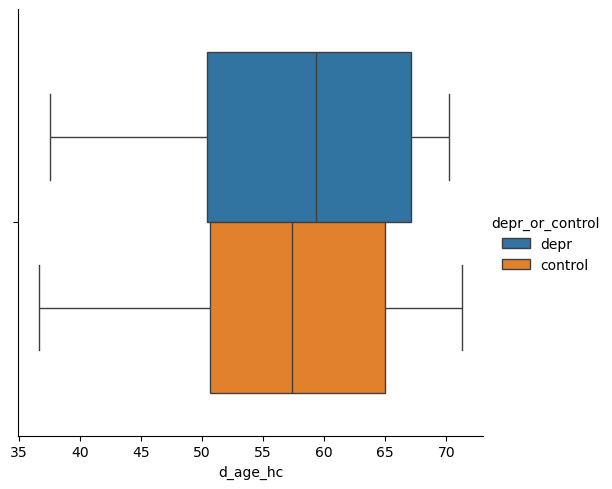

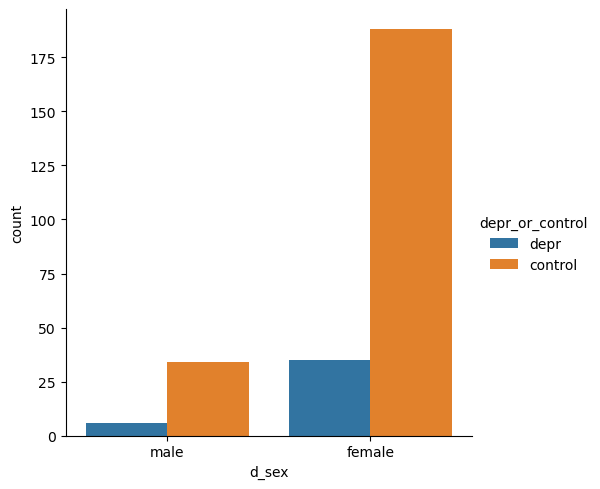

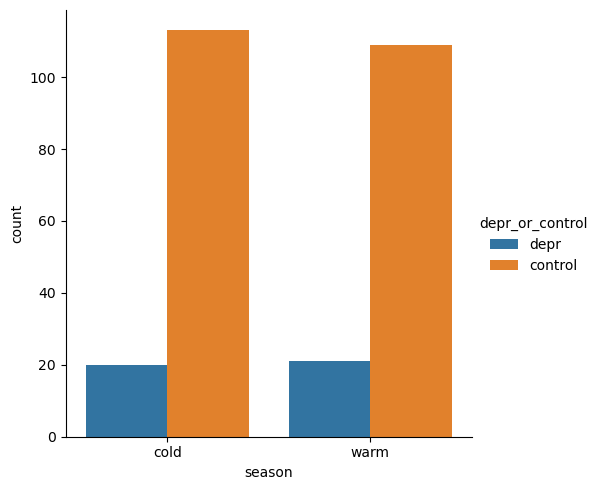

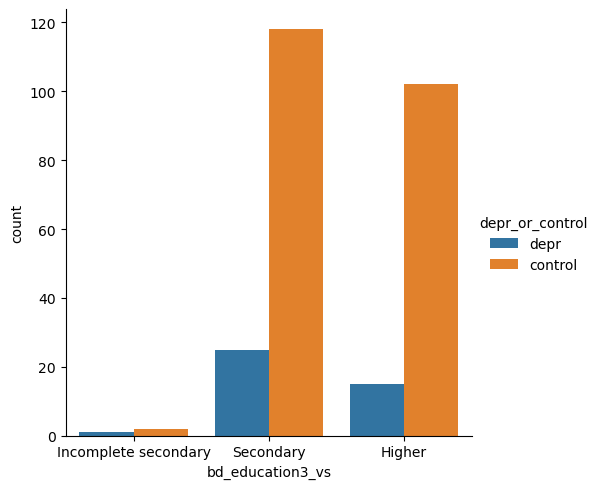

In [23]:
sns.catplot(data=depr_control_df, kind='box', x='d_age_hc', hue='depr_or_control')
sns.catplot(data=depr_control_df, kind='count', x='d_sex', hue='depr_or_control')
sns.catplot(data=depr_control_df, kind='count', x='season', hue='depr_or_control')
sns.catplot(data=depr_control_df, kind='count', x='bd_education3_vs', hue='depr_or_control')

In [24]:
depr_control_df_alt = kyh_df.loc[depr_to_control_map.index]
depr_control_df_alt['depr_or_control'] = 'depr'


depr_control_df_alt = pd.concat([
    depr_control_df_alt,
    kyh_df.loc[list(matches['ID_KYH_no_depr'].unique())].assign(depr_or_control='control')
])  

In [25]:
depr_control_df_alt[['d_sex', 'd_age_hc_grp_5yr', 'season', 'bd_education3_vs']].describe()

,d_sex,d_age_hc_grp_5yr,season,bd_education3_vs
count,263,263,263,263
unique,2,7,2,3
top,female,65+,cold,Secondary
freq,223,72,133,143


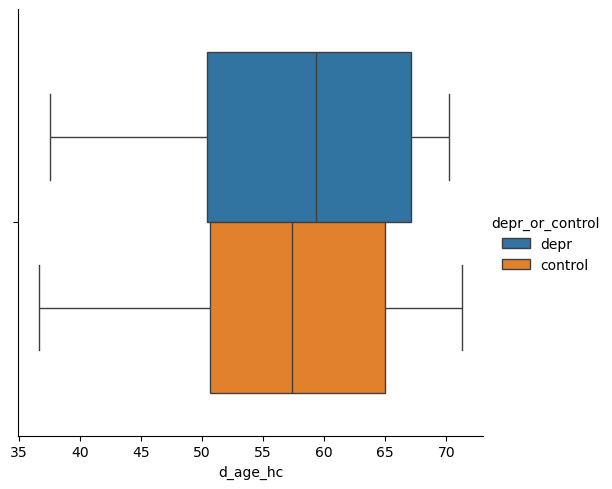

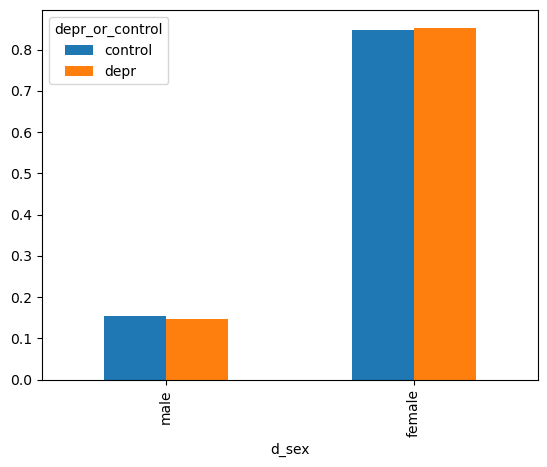

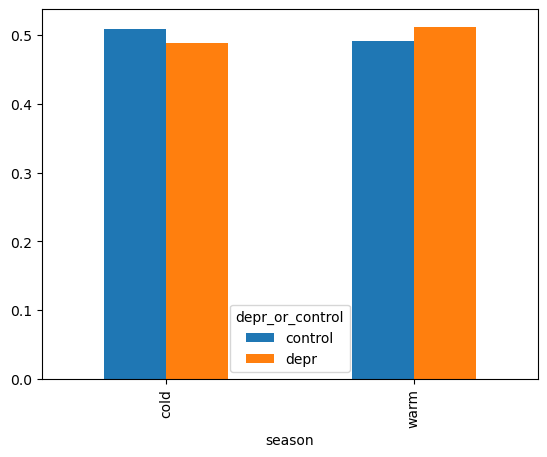

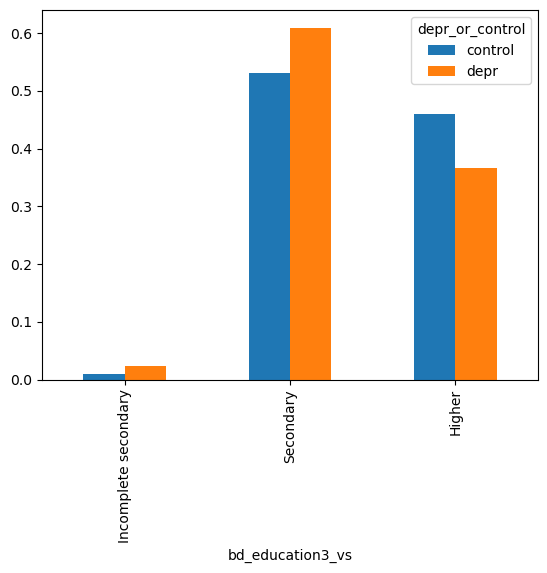

In [26]:
def crosstab(col_name):
    pd.crosstab(
        depr_control_df_alt['depr_or_control'],
        depr_control_df_alt[col_name],
        normalize='index'
    ).T.plot(kind='bar')
    
    
sns.catplot(data=depr_control_df_alt, kind='box', x='d_age_hc', hue='depr_or_control')

for col in ['d_sex', 'season', 'bd_education3_vs']:
    crosstab(col)

# Batches

In [27]:
from random import shuffle

In [28]:
if len(depr_control_df) % BATCHES_SIZE < BATCHES_SIZE * 0.7:
    last_batch_size = len(depr_control_df) % BATCHES_SIZE
    extra_samples_to_batch = last_batch_size // (len(depr_control_df) // BATCHES_SIZE) + 1 
    BATCHES_SIZE += extra_samples_to_batch
    print(f"Adjusted batch size to {BATCHES_SIZE} to avoid small last batch (less then 70% of batch size)")

Adjusted batch size to 132 to avoid small last batch (less then 70% of batch size)


In [29]:
batches = [ f'B{i // BATCHES_SIZE+1}' for i in range(len(depr_control_df)) ]
shuffle(batches)
depr_control_df['batch'] = batches

## Save data

In [30]:
if SAVE_RESULTS:
    depr_control_df.to_csv(METADATA_DIR / "kyh_metadata.csv")
    ids_map = ids_map['new_id']
    ids_map.to_csv(METADATA_DIR / "kyh_ids_map.csv")

#### File with all needed metadate (_private_)

In [ ]:
if SAVE_RESULTS:
    depr_control_df['new_id'] = depr_control_df.index.map(ids_map)
    depr_control_df = depr_control_df.merge(
        sra_table[['Run']],
        left_on='new_id',
        right_index=True,
        how='left'
    )ude
    depr_control_df.to_csv(METADATA_DIR / "all_meta.csv")
    
    depr_to_control_map_flatten.to_csv(METADATA_DIR / 'depr_to_control_map.csv')